### Finite Volume Estimation of Vertical Velocity

We estimate the vertical velocity \( w \) at the interface between levels using the **finite volume approach**:

$$
w_{k+\frac{1}{2}} = \sum_{j=k+1}^{N} \left( - \left( \nabla_h \cdot \vec{u} \right)_j \cdot \Delta z_j \right)
$$

Where:

- $\( w_{k+\frac{1}{2}} \)$: vertical velocity at the interface between depth levels $\( k \)$ and $\( k+1 \)$ (i.e., at the T-point)
- $\( \nabla_h \cdot \vec{u} \)$: horizontal divergence at level $\( j \)$
- $\( \Delta z_j \)$: vertical thickness of layer $\( j \)$
- $\( N \)$: number of vertical levels
- The summation is performed **from bottom to top**, i.e., accumulating horizontal divergence from deeper layers up to level $\( k \)$

To express $\( w \)$ as a velocity per unit area, we normalize by the horizontal area of the grid cell:

$$
w = \frac{w_{k+\frac{1}{2}}}{\Delta x \cdot \Delta y}
$$

Where:

- $\( \Delta x, \Delta y \)$: horizontal grid spacing in the x and y directions respectively

> **Note:** This method is conservative and accounts for the mass budget within each control volume (finite volume), making it suitable for gridded ocean model outputs like those from Copernicus mesh type A or T.

### Computation of Vertical Velocity from Continuity Equation

We start from the incompressible continuity equation:

$[
\nabla \cdot \vec{u} + \frac{\partial w}{\partial z} = 0
\quad \Rightarrow \quad
\frac{\partial w}{\partial z} = -\left( \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} \right)
]$

We integrate vertically from the bottom (at depth $ (z_N ))$ up to the interface $( z_{k+\frac{1}{2}} )$:

$[
w_{k+\frac{1}{2}} = \int_{z_{k+1}}^{z_N} -\left( \nabla_h \cdot \vec{u} \right) \, dz
]
$
We approximate this integral as a discrete sum:

$
[
w_{k+\frac{1}{2}} \approx \sum_{j=k+1}^{N} \left( -\left( \nabla_h \cdot \vec{u} \right)_j \cdot \Delta z_j \right)
]
$

---

### Volume Flux Formulation

We compute horizontal volume fluxes in each grid cell:

$
[
F_u = u \cdot \Delta y \cdot \Delta z, \quad
F_v = v \cdot \Delta x \cdot \Delta z
\quad \text{(units: m}^3/\text{s)}
]
$

Then compute the divergence of these fluxes:

$
[
\frac{\partial F_u}{\partial x} + \frac{\partial F_v}{\partial y}
\quad \text{(units: m}^2/\text{s)}
]
$

We multiply this by the layer thickness:

$
[
\left( \frac{\partial F_u}{\partial x} + \frac{\partial F_v}{\partial y} \right) \cdot \Delta z
\quad \text{(units: m}^3/\text{s)}
]
$

And integrate upward from the bottom:

$
[
W_{k+\frac{1}{2}} = \sum_{j=k+1}^{N} \left[ -\left( \frac{\partial F_u}{\partial x} + \frac{\partial F_v}{\partial y} \right)_j \cdot \Delta z_j \right]
]
$

This gives the vertical **volume flux** $( W_{k+\frac{1}{2}} )$ through the horizontal cell area, with units:

$
[
[W] = \text{m}^3/\text{s}
]
$

---

### Conversion to Vertical Velocity

To convert this to vertical **velocity** \( w \) in m/s, we divide by the horizontal cell area:

$
[
w_{k+\frac{1}{2}} = \frac{W_{k+\frac{1}{2}}}{\Delta x \cdot \Delta y}
\quad \text{(units: m/s)}
]
$

---

### Summary

- We used the continuity equation to derive vertical transport from horizontal divergence.
- Our computed variable \( W \) has units of m³/s (volume flux).
- Dividing by cell area recovers vertical velocity \( w \) in m/s.


In [1]:
import xarray as xr
import matplotlib.pyplot as plt
# from cmocean import cm 
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

In [2]:
ds = xr.open_dataset(r'../data/amazon2.nc')

### Interpolation of Lower layers 

In [3]:
## interp lower layers
z_orig = ds.depth  # (depth,)
z_threshold = 1000  # metros

# Dividir en superficial y profundo
z_shallow = z_orig.where(z_orig < z_threshold, drop=True)
z_deep = z_orig.where(z_orig >= z_threshold, drop=True)

# Interpolar verticalmente duplicando puntos entre capas profundas
z_deep_mid = (z_deep.shift(depth=-1)+z_deep)/2 
z_deep_mid=z_deep_mid.dropna(dim='depth')

z_new = xr.concat([z_shallow,z_deep, z_deep_mid], dim='depth').sortby('depth')

zz = xr.DataArray(
    z_new.values,
    dims=["depth"],
    coords={"depth": z_new.values},
    name="depth"
)

zz.name = "depth"  # debe coincidir con el nombre del eje de profundidad en ds

# Interpolar uo y vo a la nueva malla de profundidad
uo_interp = ds.uo.interp(depth=zz)
vo_interp = ds.vo.interp(depth=zz)

ds_interp = xr.Dataset({
    "uo": uo_interp,
    "vo": vo_interp
})

### Integration of W

In [4]:
R = 6371e3  # Earth radius in meters

# Load your u, v, and coordinates (1 time step)
u = ds_interp.uo.isel(time=0)  # (depth, lat, lon)
v = ds_interp.vo.isel(time=0)

lat = ds_interp.latitude
lon = ds_interp.longitude
depth = ds_interp.depth

##mid z
z_midi = (ds_interp.depth.shift(depth=-1) + ds_interp.depth) / 2
z_midi = z_midi.isel(depth=slice(0, -1)) 

# 1. Compute dx and dy in meters
dy = np.deg2rad(lat.diff('latitude')) * R
dy = dy.pad(latitude=(0,0), mode='edge')  # match dims

dx = np.deg2rad(lon.diff('longitude')) * R * np.cos(np.deg2rad(lat))
dx = dx.pad(longitude=(0,0), mode='edge')

# 2. Compute dz (layer thickness)
dz = depth.diff('depth')
# dz = dz.pad(depth=(0,1), mode='edge')  # pad bottom layer

# 3. Broadcast shapes for dx, dy, dz
dx_3d = dx.broadcast_like(u)
dy_3d = dy.broadcast_like(v)
dz_3d = dz.broadcast_like(u)

# 4. Compute fluxes
F_u = u * dy_3d * dz_3d  # zonal volume flux
F_v = v * dx_3d * dz_3d  # meridional volume flux

# 5. Compute divergence of volume fluxes
dF_u_dx = (F_u.shift(longitude=-1) - F_u) / dx_3d
dF_v_dy = (F_v.shift(latitude=-1) - F_v) / dy_3d

div_flux = dF_u_dx + dF_v_dy

# dz_3d = dz.broadcast_like(div_flux.isel(depth=slice(0, -1)))
# 6. Integrate from bottom to top
integrand = -div_flux.isel(depth=slice(0, -1))
dz_3d_mid = dz_3d.isel(depth=slice(0, -1))
integrand = integrand * dz_3d_mid

# Reverse for bottom-up integration
w_bottom_up = integrand.isel(depth=slice(None, None, -1)).cumsum(dim='depth', skipna=True)
w_bottom_up = w_bottom_up.isel(depth=slice(None, None, -1))  # reverse back

w_bottom_up = w_bottom_up.assign_coords(depth=z_midi)
w_bottom_up.name = 'w_bottom_up'

# Optional: interpolate to center of T cells
w_FV = ((w_bottom_up + w_bottom_up.shift(depth=-1)) / 2).fillna(0)
w_FV=w_FV.where(w_FV!=0,np.nan)
w_FV.name = "w_FV"

## divide by the area
area_3d = dx_3d * dy_3d
area_3d=area_3d.interp(depth=w_bottom_up.depth)

w= w_bottom_up / area_3d  # now has units of [m/s]
w.name = 'w_vertical'
# w =w.where(w!=0,np.nan)

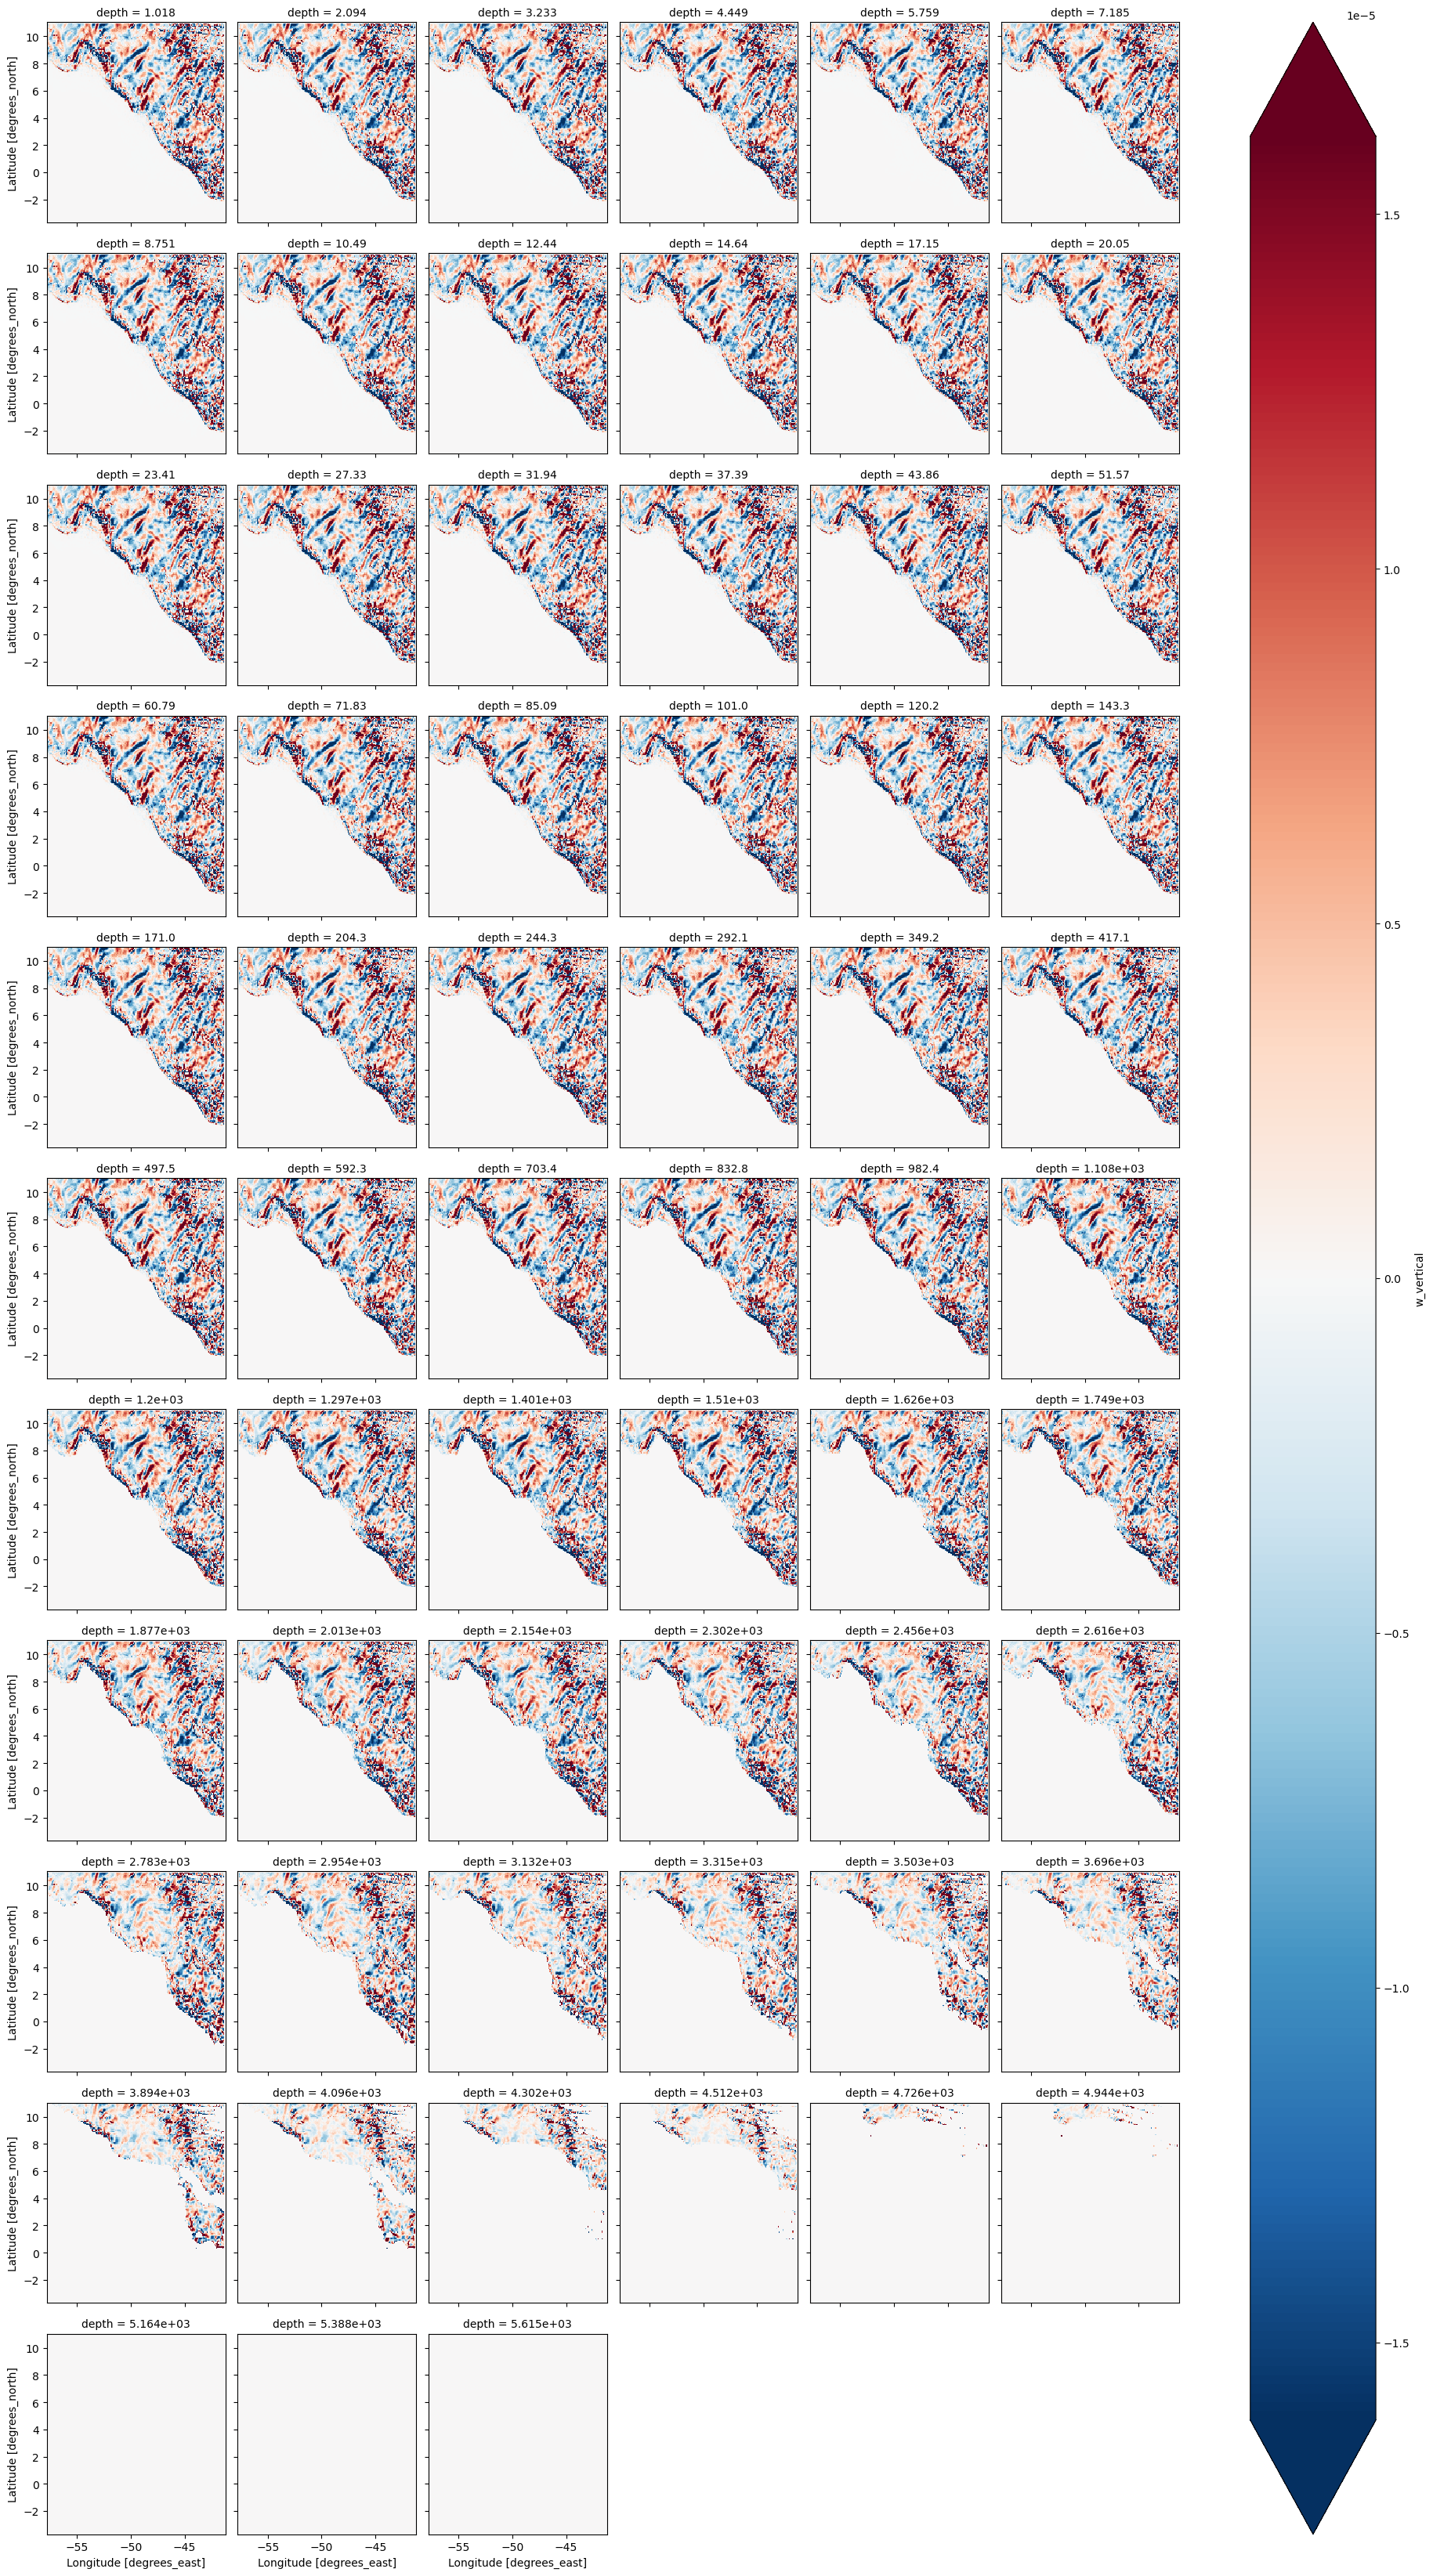

In [6]:
w.plot(x='longitude',y='latitude',col='depth',col_wrap=6, robust=True)

### Area to compare 

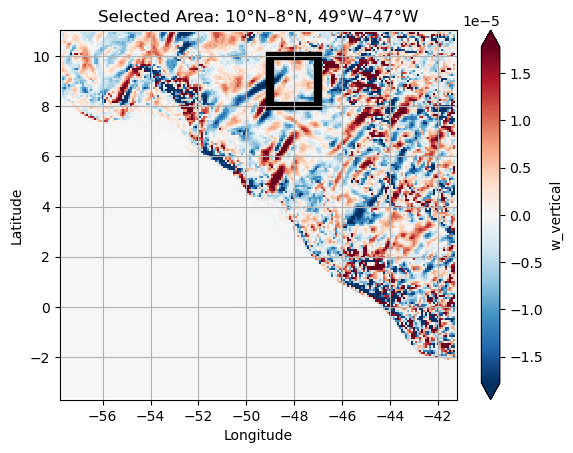

In [15]:
# Hacer el plot y capturar el eje
fig, ax = plt.subplots()
w.isel(depth=0).plot(x='longitude', y='latitude', robust=True, ax=ax)

# Añadir rectángulo al eje
rect = Rectangle(
    xy=(-49, 8), width=2, height=2,
    linewidth=6, edgecolor='black', facecolor='none', linestyle='-'
)
ax.add_patch(rect)

# Opcional: ajustar límites
# ax.set_xlim(-50, -43)
# ax.set_ylim(6, 12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Selected Area: 10°N–8°N, 49°W–47°W")
ax.grid(True)

plt.show()

In [16]:
lat_min, lat_max = 8, 10
lon_min, lon_max = -49, -47
#--- Mask for W 
mask = (
    ((w.latitude >= lat_min) & (w.latitude <= lat_max)) &
    ((w.longitude >= lon_min) & (w.longitude <= lon_max))
)

# Convert boolean to integer (1 inside the box, 0 outside)
binary_mask = mask.astype(int)

mask_3f = xr.broadcast(w.isel(depth=0)*0 + 1, binary_mask)[1]
mask_3f = mask_3f.where(mask_3f!=0,np.nan)

## ----- max for U,V in the corners
mask = (
    ((ds_interp.latitude >= lat_min) & (ds_interp.latitude <= lat_max)) &
    ((ds_interp.longitude >= lon_min) & (ds_interp.longitude <= lon_max))
)

# Convert boolean to integer (1 inside the box, 0 outside)
bmask = mask.astype(int)

# Broadcast to depth
mask_3c = xr.broadcast(ds_interp.uo.isel(depth=0)*0 + 1, bmask)[1]
mask_3c = mask_3c.where(mask_3c!=0,np.nan)

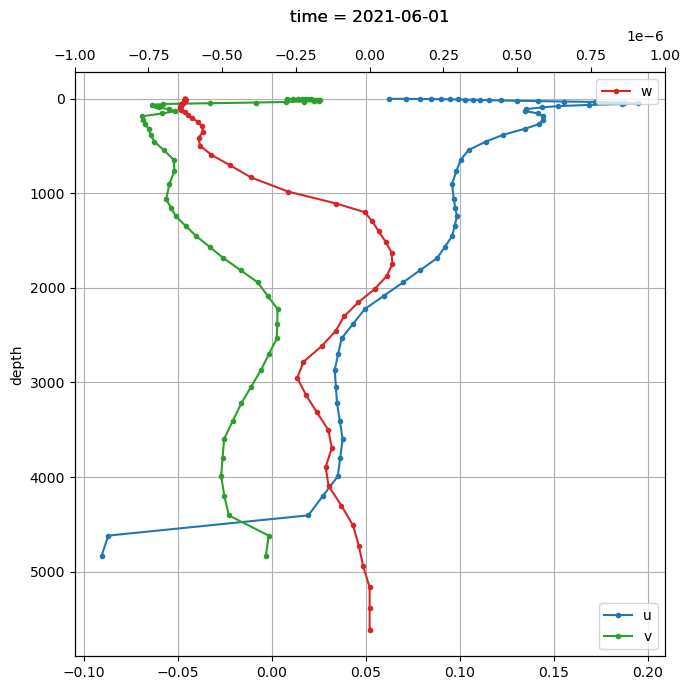

In [17]:
uu = (ds_interp.uo * mask_3c).isel(time=0)
vv = (ds_interp.vo * mask_3c).isel(time=0)
ww = (w * mask_3f)

fig, ax = plt.subplots(figsize=(7, 7))

# Eje inferior: u y v
uu.mean(dim=('latitude', 'longitude'), skipna=True).plot(
    y='depth', marker='.', label='u', ax=ax, color='tab:blue')

vv.mean(dim=('latitude', 'longitude'), skipna=True).plot(
    y='depth', marker='.', label='v', ax=ax, color='tab:green')

# ax.set_ylim(0, 1500)
ax.invert_yaxis()
ax.grid(visible=True)
ax.legend(loc='lower right')

# Eje superior: w
ax2 = ax.twiny()
ww.mean(dim=('latitude', 'longitude'), skipna=True).plot(
    y='depth', marker='.', label='w', ax=ax2, color='tab:red')

ax2.legend(loc='upper right')
ax2.set_xlim(-1e-6,1e-6)

plt.tight_layout()
# plt.grid(True)
plt.show()

* plot the div

In [9]:
# w.to_netcdf("w_fv.nc")